# Estimating Expected Probability of Default

The goal of this exercise is to estimate the **expected probability of default (PD)** of Spanish firms using supervised machine‑learning models. The goal is to understand which financial characteristics are most predictive of default events and to compare the performance of several classification algorithms commonly used in credit‑risk modeling.

The workflow covers the full modeling pipeline: data exploration, correlation analysis, feature preparation, and the implementation of multiple predictive models including Logistic Regression, Decision Tree, Random Forest, and XGBoost. Model performance is evaluated using standard metrics such as accuracy, precision, recall, and ROC AUC. SHAP values are used to interpret model outputs and highlight the drivers of predicted PDs.

In addition to comparing model performance, the project examines how predicted PDs vary across firms and reestimates selected models on the full dataset using the most influential features. The results provide practical insights into which modeling approaches deliver reliable PD estimates and which financial indicators are most relevant for assessing credit risk in a business environment.

## Table of Contents

1. [Load packages](#1.-Load-packages)
2. [Load and inspect data](#2.-Load-and-inspect-data)
3. [Setting up](#3.-Setting-up)
4. [Implementation of Loan Default Prediction Models](#4.-Implementation-of-Loan-Default-Prediction-Models)
5. [Summary and Conclusion](#5.-Summary-and-Conclusion)

## 1. Load packages

In [6]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Preprocessing & model utilities
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score,
    recall_score, precision_score, roc_curve, precision_recall_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


## 2. Load and inspect data
[↑ top](#Table-of-Contents)

In [10]:
# Load the data
file_path = "/Users/andrealorensy/Desktop/Andrea's Files/UPF PhD/Credit Life Cycle/Data/CIR_CBI_data_for_est_PDs.dta"  # Use your file path here
raw_data = pd.read_stata(file_path)

# Display basic information about the dataset
raw_data.head()

,firmID,year,cnae2009Division,firm_size,postal_code,I_overdue,LT_debt_sh,l_age,lag_l_Assets,lag_liq_ratio,...,lag_EBITDA_A,lag_inventory_sales,lag_receiv_sales,lag_current_ratio,tag,exclude,housing,NACE_grouped,low_q,overdue_CFL
0,27,2001,55,Medium,28014.0,0,0.805376,4.521789,9.899379,0.051765,...,0.165816,0.008892,0.670910,2.589375,NaN,0,0,Hospitality & Entertainment,0,NaN
1,27,2002,55,Medium,28014.0,0,0.802936,4.532599,10.008686,0.061274,...,0.157471,0.006592,0.912183,2.629214,NaN,0,0,Hospitality & Entertainment,0,NaN
2,27,2003,55,Medium,28014.0,0,0.932781,4.543295,9.988968,0.466521,...,0.143958,0.001067,0.139008,3.187269,NaN,0,0,Hospitality & Entertainment,0,NaN
3,50,2004,71,Small,28020.0,0,1.000000,1.791759,7.400620,0.130727,...,-0.043372,0.000000,0.175666,3.773196,NaN,0,0,Professional & Admin Services,0,0.0
4,50,2005,71,Small,28020.0,0,1.000000,1.945910,7.315884,0.085771,...,-0.036569,0.000000,0.126744,2.542222,NaN,0,0,Professional & Admin Services,0,0.0


#### Group by sector and aggregate counts and sum of events

In [13]:
summary = raw_data.groupby(['NACE_grouped']).agg(
    observations = ('I_overdue', 'size'),  # Total number of rows in each group
    events = ('I_overdue', 'sum')         # Sum of 'I_overdue' in each group
).reset_index()
summary['event_rate'] = summary['events'] / summary['observations']
print('Loan delinquencies by sector')
print(summary)

Loan delinquencies by sector
                    NACE_grouped  observations  events  event_rate
0                 Primary sector        220724    4391    0.019894
1                  Manufacturing        907789   16735    0.018435
2                      Utilities         93995    1190    0.012660
3                   Construction       1260510   53409    0.042371
4       Wholesale & Retail Trade       1787466   27753    0.015526
5                 Transportation         80405    1252    0.015571
6    Hospitality & Entertainment        540178   11423    0.021147
7                            ICT        172151    2376    0.013802
8                    Real Estate        714185   19569    0.027400
9  Professional & Admin Services        913427   13813    0.015122


#### Group by firm_size and NACE_grouped and aggregate counts and sum of events

In [16]:
summary = raw_data.groupby(['NACE_grouped','firm_size']).agg(
    observations = ('I_overdue', 'size'),  # Total number of rows in each group
    events = ('I_overdue', 'sum')         # Sum of 'I_overdue' in each group
).reset_index()
summary['event_rate'] = summary['events'] / summary['observations']
print('Loan delinquencies by sector and firm size')
print(summary)

Loan delinquencies by sector and firm size
                     NACE_grouped firm_size  observations  events  event_rate
0                  Primary sector     Large          4212      65    0.015432
1                  Primary sector    Medium          5437      56    0.010300
2                  Primary sector     Small         41315     713    0.017258
3                  Primary sector     Micro        169760    3557    0.020953
4                   Manufacturing     Large         33874     418    0.012340
5                   Manufacturing    Medium         50537     611    0.012090
6                   Manufacturing     Small        286735    4078    0.014222
7                   Manufacturing     Micro        536643   11628    0.021668
8                       Utilities     Large          9685      82    0.008467
9                       Utilities    Medium          2622      19    0.007246
10                      Utilities     Small          8848     120    0.013562
11                   

- <span style="color:red"> Sectors with the most loan delinquencies are the Construction and Real Estate sectors</span>

#### Check overall incidence of loan delinquencies (loan defaults)

In [22]:
print('------------ Average probability of default ------------')
event_rate = raw_data['I_overdue'].mean()
print(f"Overall event rate (including persistent occurrence of overdue loans): {event_rate:.4f}")

subset = raw_data[raw_data['exclude'] != 1]
event_rate_exclude = subset['I_overdue'].mean()
print(f"Event rate where persistent occurrence of overdue loans are excluded: {event_rate_exclude:.4f}")

subset = raw_data[(raw_data['exclude'] != 1) & (raw_data['tag'] != 1)]
event_rate_exclude = subset['I_overdue'].mean()
print(f"Event rate where persistent occurrence of overdue loans and rows w/ missing lag Xvars are excluded: {event_rate_exclude:.4f}")

# tag = 1 if lag of Xvar is missing (this filter is needed to avoid having rows w/ missing Xvars - necessary step for prediction exercise)
model_df = raw_data[(raw_data['exclude'] != 1) & (raw_data['tag'] != 1) & (raw_data['housing'] != 1)]
event_rate = model_df['I_overdue'].mean()
print(f"Overall event rate w/o housing: {event_rate:.4f}")

------------ Average probability of default ------------
Overall event rate (including persistent occurrence of overdue loans): 0.0227
Event rate where persistent occurrence of overdue loans are excluded: 0.0113
Event rate where persistent occurrence of overdue loans and rows w/ missing lag Xvars are excluded: 0.0106
Overall event rate w/o housing: 0.0086


<br>

#### **Some Remarks** 

The dataset exhibits a very low default rate, with an overall event rate of 2.27%. When persistent overdue loans are excluded, the event rate drops to 1.13%, and further decreases to 1.06% after removing observations with missing lagged variables. Excluding housing‑related firms reduces the event rate even further to 0.86%. These figures confirm that the dataset is highly imbalanced, which has direct implications for model training and evaluation. 

Because the dataset is highly imbalanced, **accuracy** becomes a misleading metric: a model that predicts “no default” for every firm would achieve very high accuracy while providing no predictive value. In credit‑risk settings, the ability to correctly identify rare default events is far more important. Metrics such as precision, recall, and ROC AUC are more appropriate for assessing model performance.

**Precision** measures how many of the firms the model labels as “default” are actually defaults. High precision means few false alarms (few false positives). This matters when incorrectly flagging a firm as risky has consequences, such as unnecessary credit tightening or manual review. 

**Recall** measures how many of the actual defaulting firms the model successfully identifies. High recall means the model misses fewer true defaults (fewer false negatives). This is critical in credit risk because missing a default can lead to financial losses. 

**ROC AUC** evaluates the model’s ability to rank firms by risk across all possible classification thresholds. It measures how well the model separates defaulting from non‑defaulting firms, independent of any specific cutoff. A higher AUC means the model consistently assigns higher PDs to firms that actually default. This makes ROC AUC especially useful for imbalanced datasets, where threshold‑dependent metrics like accuracy can be misleading. 

Together, these metrics provide a much clearer picture of model performance in rare‑event prediction than accuracy alone.

## 3. Setting up

1. [Filtering data](#3.1.-Filtering-data)
2. [Check correlation among candidate predictors](#3.2.-Check-correlation-among-candidate-predictors)
3. [Descriptive Statistics](#3.3-Descriptive-Statistics)

[↑ top](#Table-of-Contents)

#### 3.1 Filtering data

- Drop firms with persistent occurrence of overdue loans (`exclude = 1`)  <br>
  Firms that consistently exhibit overdue payments behave differently from the rest of the population and may represent structurally distressed entities. Including them could bias the model toward patterns that do not generalize to typical firms, so they are removed to maintain a cleaner learning signal.
  
- Drop rows w/ missing lag Xvars (`tag = 1`) <br>
  The model uses 1‑year lagged financial indicators to predict default probabilities. Because these lagged features are essential predictors, observations with missing values cannot be used without introducing noise or requiring imputation that may distort the target relationship. These rows are therefore removed.

- Drop firms that belong to the Construction and Real Estate sectors (`housing = 1`) <br>
  These sectors often display financial dynamics and risk patterns that differ substantially from other industries (e.g., leverage structure, cyclicality, asset composition). Excluding them helps the model focus on more homogeneous firm behavior and prevents sector‑specific effects from dominating the results.

In [41]:
model_df = raw_data[(raw_data['exclude'] != 1) & (raw_data['tag'] != 1) & (raw_data['housing'] != 1)]

# X variables
Xvars = ['l_Assets', 'leverage', 'liq_ratio', 'tang_ratio',
               'ownfunds_assets', 'finexp_sales', 'ROA', 'EBITDA_A',
               'rev_assets', 'inventory_sales', 'receiv_sales', 'current_ratio']

# Feature matrix and target
X = model_df[[f"lag_{v}" for v in Xvars]]
y = model_df['I_overdue']

#### 3.2 Check correlation among candidate predictors

We can check the correlation among the candidate predictors to make sure we do not have redundancies and multicollinearity among X's.

Multicollinearity: Where two or more predictors are highly correlated, which can distort model coefficients and affect interpretability.
Redundancy: Including highly similar variables adds little new information and can increase model complexity unnecessarily.

In [44]:
# Compute correlation matrix
corr_matrix_vars = X.corr()

corr_matrix_vars

,lag_l_Assets,lag_leverage,lag_liq_ratio,lag_tang_ratio,lag_ownfunds_assets,lag_finexp_sales,lag_ROA,lag_EBITDA_A,lag_rev_assets,lag_inventory_sales,lag_receiv_sales,lag_current_ratio
lag_l_Assets,1.000000,-0.048275,-0.117390,0.022320,-0.145097,0.091515,0.188535,0.145379,-0.331465,0.033343,0.084601,0.024031
lag_leverage,-0.048275,1.000000,-0.170819,0.317019,-0.017530,0.242977,-0.215442,-0.155235,-0.139019,0.031508,0.044939,0.014417
lag_liq_ratio,-0.117390,-0.170819,1.000000,-0.296662,-0.007329,-0.073910,0.113385,0.102010,0.129288,-0.071113,-0.044964,0.108459
lag_tang_ratio,0.022320,0.317019,-0.296662,1.000000,0.062608,0.150713,-0.041147,0.012345,-0.219542,-0.048498,-0.016600,-0.033384
lag_ownfunds_assets,-0.145097,-0.017530,-0.007329,0.062608,1.000000,0.036513,-0.222534,-0.190787,0.053855,0.014974,0.052225,0.042380
lag_finexp_sales,0.091515,0.242977,-0.073910,0.150713,0.036513,1.000000,-0.063909,-0.068338,-0.192885,0.231528,0.476972,0.065375
lag_ROA,0.188535,-0.215442,0.113385,-0.041147,-0.222534,-0.063909,1.000000,0.868426,-0.070163,-0.026689,-0.048307,0.014392
lag_EBITDA_A,0.145379,-0.155235,0.102010,0.012345,-0.190787,-0.068338,0.868426,1.000000,0.009365,-0.056181,-0.088029,-0.001929
lag_rev_assets,-0.331465,-0.139019,0.129288,-0.219542,0.053855,-0.192885,-0.070163,0.009365,1.000000,-0.102191,-0.169387,-0.065042
lag_inventory_sales,0.033343,0.031508,-0.071113,-0.048498,0.014974,0.231528,-0.026689,-0.056181,-0.102191,1.000000,0.272744,0.053491


##### **Heatmap to visualize**

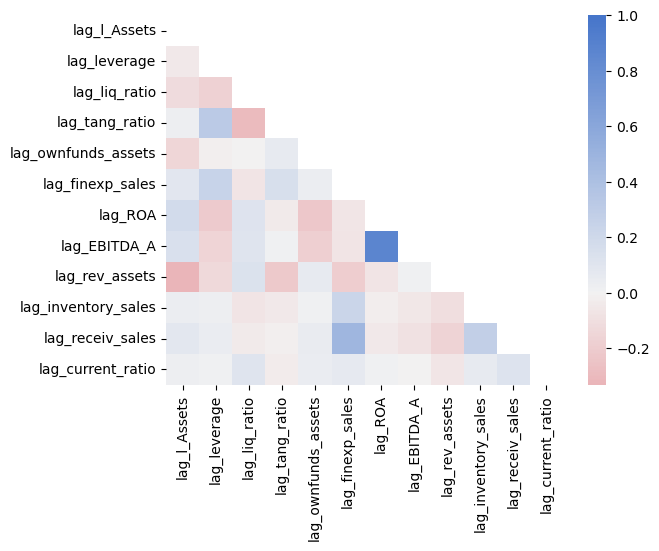

In [48]:
cmap = sns.diverging_palette(10, 255, as_cmap=True) # Create a color map
mask = np.triu(np.ones_like(corr_matrix_vars, dtype=bool)) # Create a mask to only show the lower triangle of the matrix
sns.heatmap(corr_matrix_vars, cmap=cmap, vmax=1, center=0, mask=mask) # Create a heatmap of the correlation matrix (Note: vmax=1 makes sure that the color map goes up to 1 and center=0 are used to center the color map at 0)
plt.show()

Given the very high correlation between `lag_EBITDA_A` and `lag_ROA`, we can keep one and drop the other. Since the paper of Blanco et al. (2023) uses `lag_ROA`, we will keep this variable, though presumably, these two provide the same economic insight since both measure firm profitability.

In [51]:
# X variables, excluding EBITDA_A
Xvars = ['l_Assets', 'leverage', 'liq_ratio', 'tang_ratio',
               'ownfunds_assets', 'finexp_sales', 'ROA',
               'rev_assets', 'inventory_sales', 'receiv_sales', 'current_ratio']

# Feature matrix and target
X = model_df[[f"lag_{v}" for v in Xvars]]
y = model_df['I_overdue']

#### 3.3 Descriptive Statistics

In [54]:
# Note that the data imported here has been winsorized at the 1% level at the tails.
X.describe().T

,count,mean,std,min,25%,50%,75%,max
lag_l_Assets,4561908.0,6.055573,1.574890,5.988365e-01,5.000922,5.967659,7.008442,10.515090
lag_leverage,4561908.0,0.285213,0.311865,-6.062475e-03,0.026792,0.198089,0.444526,2.472378
lag_liq_ratio,4561908.0,0.156845,0.207051,-3.323733e-01,0.017784,0.076731,0.223881,1.000000
lag_tang_ratio,4561908.0,0.321558,0.284261,0.000000e+00,0.069469,0.243804,0.526066,0.998614
lag_ownfunds_assets,4561908.0,0.128991,0.227177,3.174194e-04,0.014509,0.045407,0.143187,3.270646
lag_finexp_sales,4561908.0,0.038243,0.132982,0.000000e+00,0.002187,0.009427,0.026190,2.540373
lag_ROA,4561908.0,-0.002721,0.218991,-2.763899e+00,-0.009173,0.013125,0.050031,0.713721
lag_rev_assets,4561908.0,1.666260,1.736127,1.422184e-08,0.604697,1.235164,2.116063,14.297154
lag_inventory_sales,4561908.0,0.297142,1.711296,0.000000e+00,0.000000,0.057145,0.221239,71.892097
lag_receiv_sales,4561908.0,0.418142,1.476262,-5.891107e-02,0.059582,0.172535,0.336935,26.490797


## 4. Implementation of Loan Default Prediction Models

1. [Pre-processing](#4.1-Pre-processing)
2. [Prediction Models](#4.2-Prediction-Models)  <br>
   - [Logistic Regression](#4.2.1-Logistic-Regression)  <br>
   - [Decision Tree](#4.2.2-Decision-Tree) <br>
   - [Random Forest](#4.2.3-Random-Forest) <br>
   - [XGBoost](#4.2.4-XGBoost)
3. [Overview of the Results](#4.3-Overview-of-the-Results)
4. [Implementation of Logistic and XGBoost on Full Sample](#4.4-Implementation-of-Logistic-and-XGBoost-on-Full-Sample)
   - [Display top 5 features](#Display-top-5-features)

[↑ top](#Table-of-Contents)

### 4.1 Pre-processing

#### 4.1.1 Splitting the Data into Training and Test Sets
Before we can train a machine learning model, we need to split our dataset into a training set and a test set.

We follow Alonso Robisco and Carbó Martínez (2022) and use 80% of the data for training and 20% for testing. We will also set the stratify argument to y to make sure that the distribution of the target variable is the same in the training and test sets. Otherwise, we might randomly not have any defaulted loans in the test set, which would make it impossible to correctly evaluate our model.

We will also standardize the variables.

In [77]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### 4.1.2 Scaling Features

To improve the performance of our machine learning model, we should scale the features. 

In [80]:
# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 4.1.3 Evaluation Criertia
We will evaluate the performance of our machine-learning models using the following metrics:

- Accuracy: The proportion of correctly classified instances
- Precision: The proportion of true positive predictions among all positive predictions
- Recall: The proportion of true positive predictions among all actual positive instances
- ROC AUC: The area under the receiver operating characteristic curve

Furthermore, we will plot the ROC curve for each model to visualize the trade-off between the true positive rate and the false positive rate. 

To make the evaluation of our models more convenient, we will define a function that computes these metrics and plots the ROC curve for a given model.

In [152]:
def evaluate_model(clf, X_train, y_train, X_test, y_test, label=''):

    # Compute predictions and probabilities for the training and test set
    y_pred_train = clf.predict(X_train)
    y_proba_train = clf.predict_proba(X_train)
    y_pred_test = clf.predict(X_test)
    y_proba_test = clf.predict_proba(X_test)

    # Print accuracy measures
    print(f"--------------------------------------------------------------")
    print(f"Metrics: {label}")
    print(f"--------------------------------------------------------------")
    print(f"Accuracy (Train): {accuracy_score(y_train, y_pred_train)}")
    print(f"Precision (Train): {precision_score(y_train, y_pred_train)}")
    print(f"Recall (Train): {recall_score(y_train, y_pred_train)}")
    print(f"ROC AUC (Train): {roc_auc_score(y_train, y_proba_train[:, 1])}")
    print(f"--------------------------------------------------------------")
    print(f"Accuracy (Test): {accuracy_score(y_test, y_pred_test)}")
    print(f"Precision (Test): {precision_score(y_test, y_pred_test)}")
    print(f"Recall (Test): {recall_score(y_test, y_pred_test)}")
    print(f"ROC AUC (Test): {roc_auc_score(y_test, y_proba_test[:, 1])}")
    print(f"--------------------------------------------------------------")

    # Compute the ROC curve
    fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_proba_train[:, 1])
    fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_proba_test[:, 1])

    # Plot the ROC curve
    plt.figure(figsize=(5, 3))
    plt.plot(fpr_train, tpr_train, label = "Train") 
    plt.plot(fpr_test, tpr_test, label = "Test")
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve: {label}')
    plt.legend()
    plt.show()

### 4.2 Prediction Models

   - [Logistic Regression](#4.2.1-Logistic-Regression)  <br>
   - [Decision Tree](#4.2.2-Decision-Tree)  <br>
   - [Random Forest](#4.2.3-Random-Forest)

[↑ Sec. 4](#4.-Implementation-of-Loan-Default-Prediction-Models)

#### **4.2.1 Logistic Regression**

We will use the `LogisticRegression` class from the `sklearn.linear_model` module to train a logistic regression model. We will use the `lbfgs` solver (default) and set the `max_iter` parameter to 5000 to make sure that the optimization algorithm converges. We will also set the `penalty` parameter to None to avoid regularization (e.g. `L1` (lasso) or `L2` (ridge)).

In [96]:
clf_logistic = LogisticRegression(penalty = None, solver = 'lbfgs', max_iter = 5000, class_weight='balanced').fit(X_train_scaled, y_train)

Then evaluate the performance of the logistic regression model

--------------------------------------------------------------
Metrics: Logistic Regression
--------------------------------------------------------------
Accuracy (Train): 0.7089487785537081
Precision (Train): 0.018814325922675866
Recall (Train): 0.6438566225800268
ROC AUC (Train): 0.7270297617642075
--------------------------------------------------------------
Accuracy (Test): 0.7085979337602013
Precision (Test): 0.019005297475031782
Recall (Test): 0.6515015974440894
ROC AUC (Test): 0.7300285475733959
--------------------------------------------------------------


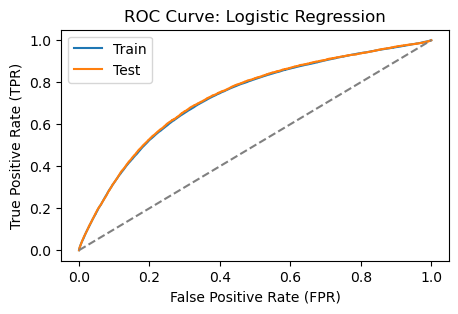

In [154]:
evaluate_model(clf_logistic, X_train_scaled, y_train, X_test_scaled, y_test, label = 'Logistic Regression')

- <span style="color:red"> The logistic regression model performs satisfactorily, with an AUC above 0.70. </span>

**4.2.1.1 Plot feature importances**

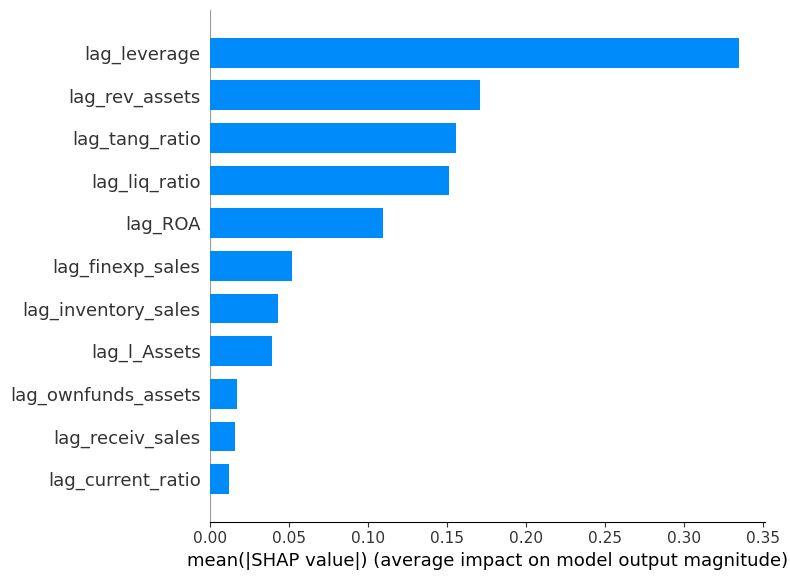

In [119]:
# Fix: use feature names from the original X_train
feature_names = X_train.columns.tolist()

# Use KernelExplainer for logit (because it’s linear)
explainer_logit = shap.Explainer(clf_logistic, X_train_scaled, feature_names=feature_names)
shap_values_logit = explainer_logit(X_test_scaled)

shap.summary_plot(shap_values_logit, X_test_scaled, plot_type="bar", feature_names=feature_names)

#### **4.2.2 Decision Tree**
Let’s now train a decision tree classifier. We will use the `DecisionTreeClassifier` class from the `sklearn.tree` module to train a decision tree classifier. We will set the `max_depth` parameter to 10.

A `DecisionTreeClassifier` is a supervised learning algorithm used for classification tasks. It builds a tree-like model of decisions based on feature values to predict the target label (class).

Think of it like a **flowchart**:
- At each **node**, it asks a yes/no question about a feature.
- Depending on the answer, it goes left or right down the tree.
- Eventually, it reaches a **leaf** node, which contains the predicted class.

[↑ Sec. 4](#4.-Implementation-of-Loan-Default-Prediction-Models)

In [147]:
clf_tree = DecisionTreeClassifier(max_depth=10, class_weight='balanced').fit(X_train_scaled, y_train)

Then evaluate the performance of the decision tree classifier.

--------------------------------------------------------------
Metrics: Decision Tree
--------------------------------------------------------------
Accuracy (Train): 0.737142028855254
Precision (Train): 0.02388758061288883
Recall (Train): 0.7437224458501054
ROC AUC (Train): 0.8127876525442349
--------------------------------------------------------------
Accuracy (Test): 0.7354178403344214
Precision (Test): 0.021482334334449175
Recall (Test): 0.6700319488817892
ROC AUC (Test): 0.7608904537073786
--------------------------------------------------------------


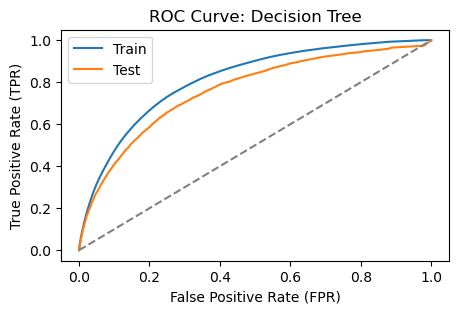

In [156]:
evaluate_model(clf_tree, X_train_scaled, y_train, X_test_scaled, y_test, label = 'Decision Tree')

##### **4.2.2.1 Plot the Decision Tree**

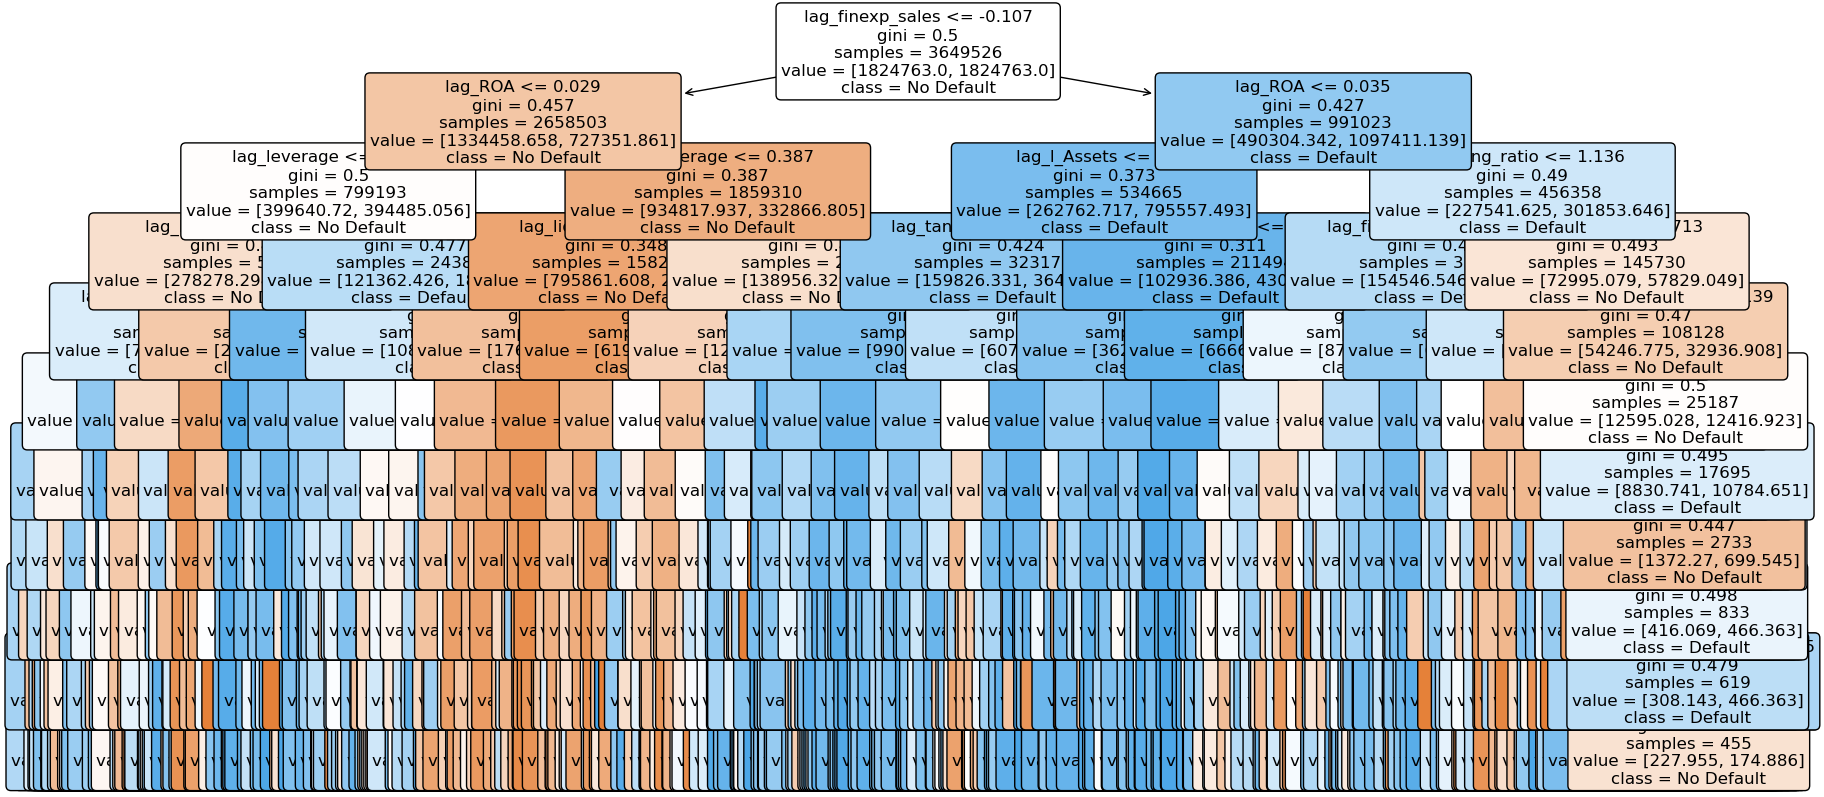

In [159]:
from sklearn.tree import plot_tree

# Plot the tree
plt.figure(figsize=(20,10))  # Adjust size as needed

feature_names = X_train.columns.tolist()  # Convert Index to list

plot_tree(
    clf_tree, 
    feature_names=feature_names,  # if X_train is a DataFrame
    class_names=['No Default', 'Default'],  # adjust to your classes
    filled=True,  # colors nodes by majority class
    rounded=True,  # rounded corners
    fontsize=12
)
plt.show()

##### **4.2.2.2 Extract the Decision Rule as Text**

In [162]:
from sklearn.tree import export_text

rules = export_text(clf_tree, feature_names=X_train.columns.tolist())
#print(rules)

##### **4.2.2.3 Plot Feature Importances**

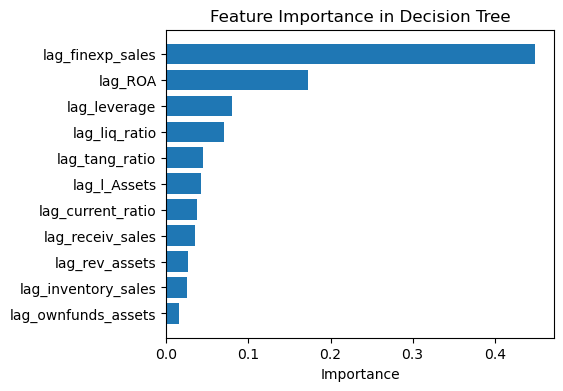

In [171]:
# Get importances and match with feature names
importances = clf_tree.feature_importances_
features = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(5, 4))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.gca().invert_yaxis()  # Most important at the top
plt.show()

#### **4.2.3 Random Forest**

Random Forest is an ensemble learning method that operates by constructing multiple decision trees during training. It combines the output of multiple decision trees to improve predictive accuracy and control overfitting (an issue w/ `DecisionTreeClassfier`).

In a random forest, many decision trees are trained, but each tree receives only a bootstrapped sample of observations (i.e., a random sample of observations with replacement that matches the original number of observations), and each node considers only a subset of features when determining the best split. This forest of randomized decision trees (hence the name) votes to determine the predicted class.

We will use the `RandomForestClassifier` class from the `sklearn.ensemble` module to train a random forest classifier. We will set the `max_depth` parameter to 15 (set a lower `max_depth` for large datasets to ease computational burden) and the `n_estimators` parameter to 100 as in Alonso Robisco and Carbó Martínez (2022).

[↑ Sec. 4](#4.-Implementation-of-Loan-Default-Prediction-Models)

In [179]:
clf_forest = RandomForestClassifier(
    max_depth=15,
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1  # use all available CPU cores
).fit(X_train_scaled, y_train)

Then, let’s evaluate the performance of the random forest classifier

--------------------------------------------------------------
Metrics: Random Forest
--------------------------------------------------------------
Accuracy (Train): 0.9164203789752423
Precision (Train): 0.07806305223112163
Recall (Train): 0.8089259472238196
ROC AUC (Train): 0.9420758267124768
--------------------------------------------------------------
Accuracy (Test): 0.911018630354391
Precision (Test): 0.0392191347168484
Recall (Test): 0.3989776357827476
ROC AUC (Test): 0.7870048127383527
--------------------------------------------------------------


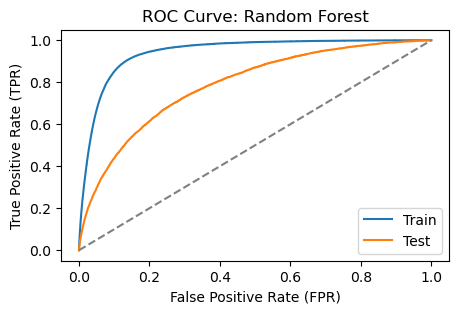

Elapsed time: 21.65 seconds


In [197]:
import time
start = time.time()

evaluate_model(clf_forest, X_train_scaled, y_train, X_test_scaled, y_test, label = 'Random Forest')

time.sleep(2)
end = time.time()
print(f"Elapsed time: {end - start:.2f} seconds")

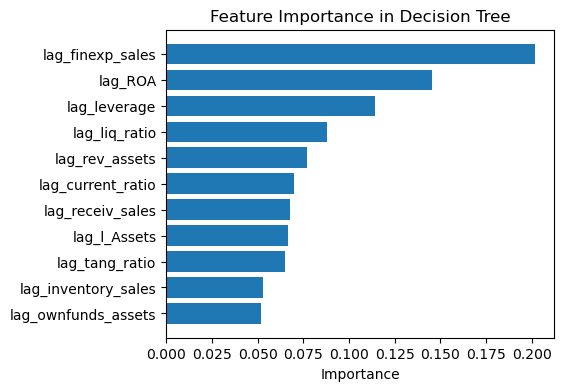

In [184]:
# Get importances and match with feature names
importances_rf = clf_forest.feature_importances_
feature_names = X_train.columns
feature_importance_df_rf = pd.DataFrame({'Feature': features, 'Importance': importances_rf})
feature_importance_df_rf = feature_importance_df_rf.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(5, 4))
plt.barh(feature_importance_df_rf['Feature'], feature_importance_df_rf['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.gca().invert_yaxis()  # Most important at the top
plt.show()

#### **4.2.4 XGBoost**

`XGBoost` (which stands for Extreme Gradient Boosting) is a very popular gradient boosting algorithm in the machine learning space. Though it is not always a tree-based model, it is frequently applied to ensembles of decision trees. Note that `XGBoost` is known for being computationally intensive.

[↑ Sec. 4](#4.-Implementation-of-Loan-Default-Prediction-Models)

In [192]:
# Calculate class imbalance ratio (only for binary classification: 0 and 1)
pos = sum(y_train == 1)
neg = sum(y_train == 0)
scale_pos_weight = neg / pos

clf_xgb = XGBClassifier(
    max_depth=5,
    n_estimators=40,
    random_state=42,
    scale_pos_weight=scale_pos_weight,  # to handle class imbalance (XGBoost does not support the `class_weight` parameter)
    eval_metric='logloss'  # prevent warning
).fit(X_train_scaled, y_train)

Then, let’s evaluate the performance of the XGBoost classifier

--------------------------------------------------------------
Metrics: XGBoost
--------------------------------------------------------------
Accuracy (Train): 0.7359596835315052
Precision (Train): 0.023703456971262405
Recall (Train): 0.7411347517730497
ROC AUC (Train): 0.8159027091017972
--------------------------------------------------------------
Accuracy (Test): 0.7354759300380762
Precision (Test): 0.022902603664416585
Recall (Test): 0.7162939297124601
ROC AUC (Test): 0.8005041417887713
--------------------------------------------------------------


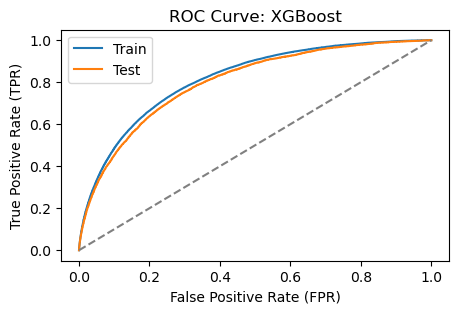

Elapsed time: 7.05 seconds


In [195]:
import time
start = time.time()

evaluate_model(clf_xgb, X_train_scaled, y_train, X_test_scaled, y_test, label = 'XGBoost')

time.sleep(2)
end = time.time()
print(f"Elapsed time: {end - start:.2f} seconds")

                Feature  Importance
5      lag_finexp_sales    0.359468
6               lag_ROA    0.159840
1          lag_leverage    0.088679
3        lag_tang_ratio    0.066364
2         lag_liq_ratio    0.063543
8   lag_inventory_sales    0.059276
10    lag_current_ratio    0.052455
9      lag_receiv_sales    0.046755
7        lag_rev_assets    0.043431
0          lag_l_Assets    0.038917
4   lag_ownfunds_assets    0.021272


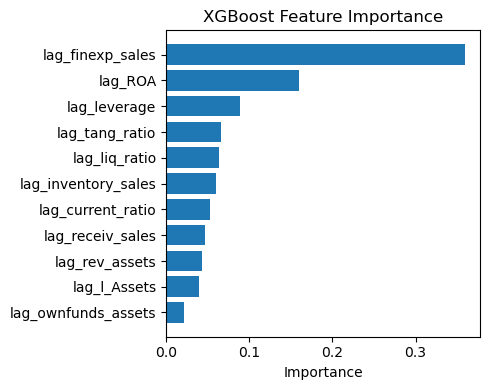

In [199]:
# Get feature importances
importances = clf_xgb.feature_importances_

# Create a DataFrame for easy viewing
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the DataFrame
print(feature_importance_df)

# Optional: Plot
plt.figure(figsize=(5, 4))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.3 Overview of the Results

[↑ Sec. 4](#4.-Implementation-of-Loan-Default-Prediction-Models)

In [206]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'ROC AUC (Train)': [
        roc_auc_score(y_train, clf_logistic.predict_proba(X_train_scaled)[:, 1]), 
        roc_auc_score(y_train, clf_tree.predict_proba(X_train_scaled)[:, 1]), 
        roc_auc_score(y_train, clf_forest.predict_proba(X_train_scaled)[:, 1]), 
        roc_auc_score(y_train, clf_xgb.predict_proba(X_train_scaled)[:, 1])
    ],
    'ROC AUC (Test)': [
        roc_auc_score(y_test, clf_logistic.predict_proba(X_test_scaled)[:, 1]), 
        roc_auc_score(y_test, clf_tree.predict_proba(X_test_scaled)[:, 1]), 
        roc_auc_score(y_test, clf_forest.predict_proba(X_test_scaled)[:, 1]), 
        roc_auc_score(y_test, clf_xgb.predict_proba(X_test_scaled)[:, 1])
    ]
})
results

,Model,ROC AUC (Train),ROC AUC (Test)
0,Logistic Regression,0.727030,0.730029
1,Decision Tree,0.812788,0.760890
2,Random Forest,0.942076,0.787005
3,XGBoost,0.815903,0.800504


#### Get predicted probabilities across all methods

In [211]:
probs_logistic = clf_logistic.predict_proba(X.values)[:, 1]
probs_tree     = clf_tree.predict_proba(X.values)[:, 1]
probs_forest   = clf_forest.predict_proba(X.values)[:, 1]
probs_xgb      = clf_xgb.predict_proba(X.values)[:, 1]

# Create DataFrame with predicted probs, index aligned with model_df
probs_df = pd.DataFrame({
    'prob_Logistic_Regression': probs_logistic,
    'prob_Decision_Tree': probs_tree,
    'prob_Random_Forest': probs_forest,
    'prob_XGBoost': probs_xgb
}, index=model_df.index)

# Concatenate predicted probabilities as new columns to model_df
# Select only the columns you want from model_df
subset_df = model_df[['firmID', 'year', 'cnae2009Division', 'I_overdue']].reset_index(drop=True)

# Make sure predicted probabilities df has the same index/reset index
probs_df = probs_df.reset_index(drop=True)

# Combine them horizontally (side by side)
final_df = pd.concat([subset_df, probs_df], axis=1)

model_df_with_probs = pd.concat([model_df, probs_df], axis=1)

In [213]:
model_df_with_probs.head()

,firmID,year,cnae2009Division,firm_size,postal_code,I_overdue,LT_debt_sh,l_age,lag_l_Assets,lag_liq_ratio,...,tag,exclude,housing,NACE_grouped,low_q,overdue_CFL,prob_Logistic_Regression,prob_Decision_Tree,prob_Random_Forest,prob_XGBoost
0,27.0,2001.0,55.0,Medium,28014.0,0.0,0.805376,4.521789,9.899379,0.051765,...,NaN,0.0,0.0,Hospitality & Entertainment,0.0,NaN,0.538150,0.615490,0.195449,0.610887
1,27.0,2002.0,55.0,Medium,28014.0,0.0,0.802936,4.532599,10.008686,0.061274,...,NaN,0.0,0.0,Hospitality & Entertainment,0.0,NaN,0.544532,0.615490,0.190372,0.647458
2,27.0,2003.0,55.0,Medium,28014.0,0.0,0.932781,4.543295,9.988968,0.466521,...,NaN,0.0,0.0,Hospitality & Entertainment,0.0,NaN,0.511030,0.000000,0.198101,0.507598
3,50.0,2004.0,71.0,Small,28020.0,0.0,1.000000,1.791759,7.400620,0.130727,...,NaN,0.0,0.0,Professional & Admin Services,0.0,0.0,0.394144,0.752301,0.346435,0.672423
4,50.0,2005.0,71.0,Small,28020.0,0.0,1.000000,1.945910,7.315884,0.085771,...,NaN,0.0,0.0,Professional & Admin Services,0.0,0.0,0.424609,0.576891,0.363055,0.798299


#### Summary of Results

In [215]:
results_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy Test': [
        roc_auc_score(y_test, clf_logistic.predict_proba(X_test_scaled)[:, 1]), 
        roc_auc_score(y_test, clf_tree.predict_proba(X_test_scaled)[:, 1]), 
        roc_auc_score(y_test, clf_forest.predict_proba(X_test_scaled)[:, 1]), 
        roc_auc_score(y_test, clf_xgb.predict_proba(X_test_scaled)[:, 1])
    ],
    'Precision Test': [
        precision_score(y_test, clf_logistic.predict(X_test_scaled)),
        precision_score(y_test, clf_tree.predict(X_test_scaled)),
        precision_score(y_test, clf_forest.predict(X_test_scaled)),
        precision_score(y_test, clf_xgb.predict(X_test_scaled))
    ],
    'Recall Test': [
        recall_score(y_test, clf_logistic.predict(X_test_scaled)),
        recall_score(y_test, clf_tree.predict(X_test_scaled)),
        recall_score(y_test, clf_forest.predict(X_test_scaled)),
        recall_score(y_test, clf_xgb.predict(X_test_scaled))
    ],
    'ROC AUC': [
        roc_auc_score(y_test, clf_logistic.predict_proba(X_test_scaled)[:, 1]), 
        roc_auc_score(y_test, clf_tree.predict_proba(X_test_scaled)[:, 1]), 
        roc_auc_score(y_test, clf_forest.predict_proba(X_test_scaled)[:, 1]), 
        roc_auc_score(y_test, clf_xgb.predict_proba(X_test_scaled)[:, 1])
    ]
})
results_summary

,Model,Accuracy Test,Precision Test,Recall Test,ROC AUC
0,Logistic Regression,0.730029,0.019005,0.651502,0.730029
1,Decision Tree,0.760890,0.021482,0.670032,0.760890
2,Random Forest,0.787005,0.039219,0.398978,0.787005
3,XGBoost,0.800504,0.022903,0.716294,0.800504


#### **Interpretation**

1. Logistic Regression <br>
Logistic regression provides a solid baseline with an AUC of 0.730 and recall of 0.652, meaning it captures a reasonable share of actual defaults. Precision is extremely low (0.019), which is expected given the rarity of default events. Despite being outperformed by tree‑based models, logistic regression remains valuable because it is transparent, stable, and easy to interpret—qualities that matter in credit‑risk settings.

2. Decision Tree <br>
The decision tree improves slightly on logistic regression, achieving higher recall (0.670) and AUC (0.761). Precision remains low (0.021), but the model shows better ability to separate risky from non‑risky firms. While still simple, it captures some nonlinear patterns that logistic regression cannot.

3. Random Forest <br>
The random forest shows very high accuracy (0.910), but this is misleading in an imbalanced dataset. Its recall drops to 0.407, meaning it misses many defaults. The AUC (0.787) indicates good ranking ability, but the default classification threshold is too conservative. 

4. XGBoost <br>
XGBoost delivers the strongest performance overall. It achieves the highest recall (0.719) and the highest AUC (0.800), indicating superior ability to detect defaults and rank firms by risk. Precision remains low (0.023), but this is typical in rare‑event prediction. Among all models, XGBoost provides the best balance between detection power and discriminatory ability.

✔️ Overall takeaway <br>
**XGBoost** is the *best-performing model*, offering the highest recall and AUC, which are the most relevant metrics for default prediction. Decision Trees follow as a moderate improvement over logistic regression. **Logistic regression** remains a *useful benchmark* due to its interpretability, even though it is outperformed by tree‑based methods. Random Forest achieves high accuracy but fails to identify many defaults, making accuracy an unreliable metric in this imbalanced context.

#### Save and export the results

In [226]:
import os

# Path to save
outpath = r"/Users/andrealorensy/Desktop/Andrea's Files/UPF PhD/Credit Life Cycle/Data/"
filename = "predicted_probabilities.dta"
full_path = os.path.join(outpath, filename)

final_df.to_stata(full_path, write_index=False)

## 4.4 Implementation of Logistic and XGBoost on Full Sample

The modeling process followed a standard and robust credit‑risk workflow. First, the dataset was split into training and test sets to allow for unbiased model evaluation. All preprocessing steps—such as scaling—were fitted only on the training data to avoid information leakage. Multiple classification models (Logistic Regression, Decision Tree, Random Forest, and XGBoost) were then trained on the training set and evaluated on the test set using accuracy, precision, recall, and ROC AUC. These metrics allowed us to compare model performance, with particular emphasis on recall and AUC, which are most relevant for default prediction in imbalanced datasets. Logistic regression was included as a benchmark model because it remains widely used in credit‑risk modeling due to its transparency and interpretability.

After identifying XGBoost as the best‑performing model, the final step was to retrain the selected models on the full dataset. This is standard practice once model selection is complete, as it allows the model to learn from all available information. The fully-trained models were then used to generate probabilities of default (PDs) for the entire sample. Feature importance was extracted from both XGBoost and Logistic Regression to support interpretability and provide insight into the key drivers of default risk.

[↑ Sec. 4](#4.-Implementation-of-Loan-Default-Prediction-Models)

In [234]:
# --- Train XGBoost on full data ---
# Calculate class imbalance ratio (only for binary classification: 0 and 1)
pos = sum(y == 1)
neg = sum(y == 0)
scale_pos_weight = neg / pos

clf_xgb = XGBClassifier(
    max_depth=5,
    n_estimators=40,
    random_state=42,
    scale_pos_weight=scale_pos_weight,  # to handle class imbalance (XGBoost does not support the `class_weight` parameter)
    eval_metric='logloss'  # prevent warning
).fit(X, y)

# Get top 5 XGBoost features
xgb_importances = pd.Series(clf_xgb.feature_importances_, index=X.columns)
top5_xgb = xgb_importances.sort_values(ascending=False).head(5).index.tolist()

# --- Train Logistic Regression on full data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf_logistic = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf_logistic.fit(X_scaled, y)

# Get top 5 Logistic Regression features (by absolute value of coefficients)
log_coeffs = pd.Series(clf_logistic.coef_[0], index=X.columns)
top5_logistic = log_coeffs.abs().sort_values(ascending=False).head(5).index.tolist()

#### **Display top 5 features**

In [249]:
print(f"Top 5 - Logistic: {top5_logistic}")
print(f"Top 5 - XGBoost: {top5_xgb}")

Top 5 - Logistic: ['lag_leverage', 'lag_ROA', 'lag_rev_assets', 'lag_liq_ratio', 'lag_tang_ratio']
Top 5 - XGBoost: ['lag_finexp_sales', 'lag_ROA', 'lag_leverage', 'lag_liq_ratio', 'lag_tang_ratio']


**Discussion of features**

The top 5 features selected by Logistic Regression and XGBoost show a strong overlap in the main drivers of default risk, including profitability (ROA), leverage, liquidity, and asset tangibility. Logistic Regression highlights variables with clear linear relationships, while XGBoost additionally selects financial expenses relative to sales, reflecting its ability to capture nonlinear interactions and threshold effects. The consistency across models reinforces the economic relevance of these predictors, while the differences illustrate how more flexible algorithms can uncover patterns that linear models may understate.

#### **Rerun the model using the top5 features**

In [239]:
# --- Retrain Logistic Regression on top 5 ---
scaler_top5 = StandardScaler()
X_scaled_top5 = scaler_top5.fit_transform(X[top5_logistic])
clf_log_top5 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf_log_top5.fit(X_scaled_top5, y)

# Predict and AUC
probs_logistic_top5 = clf_log_top5.predict_proba(X_scaled_top5)[:, 1]
auc_logistic_top5 = roc_auc_score(y, probs_logistic_top5)

# --- Retrain XGBoost on top 5 ---
clf_xgb_top5 = XGBClassifier(max_depth=5, n_estimators=40, scale_pos_weight=scale_pos_weight, 
                             eval_metric='logloss', random_state=42)
clf_xgb_top5.fit(X[top5_xgb], y)

# Predict and AUC
probs_xgb_top5 = clf_xgb_top5.predict_proba(X[top5_xgb])[:, 1]
auc_xgb_top5 = roc_auc_score(y, probs_xgb_top5)

# --- Print results ---
print(f"AUC (Logistic, Top 5): {auc_logistic_top5:.4f}")
print(f"AUC (XGBoost, Top 5): {auc_xgb_top5:.4f}")

AUC (Logistic, Top 5): 0.7186
AUC (XGBoost, Top 5): 0.7895


#### **Interpretation of the Top‑5 Feature Models**

Using only the top 5 features, both models experience a small drop in performance compared to the full‑feature versions, but the ranking between models remains the same. Logistic Regression with its top 5 features achieves an AUC of 0.7186, only slightly below its full‑model AUC, indicating that most of its predictive power is concentrated in a small set of linear drivers. XGBoost with its top 5 features reaches an AUC of 0.7895, again slightly below the full model but still clearly superior. This suggests that XGBoost captures additional nonlinear interactions in the full feature set, but its strongest signals also come from a small core of highly informative variables.

Overall, rerunning the models with only the top 5 features confirms that the most important predictors carry a large share of the signal. Logistic Regression remains interpretable and stable, while XGBoost continues to deliver the best discriminatory power even under feature reduction.

In [ ]:
# Create DataFrame with predicted probs, index aligned with model_df
probs_df_full = pd.DataFrame({
    'prob_Logistic_top5': probs_logistic_top5,
    'prob_XGBoost_top5': probs_xgb_top5
}, index=model_df.index)

# Concatenate predicted probabilities as new columns to model_df
# Select only the columns you want from model_df
subset_df = model_df[['firmID', 'year', 'cnae2009Division', 'I_overdue']].reset_index(drop=True)

# Make sure predicted probabilities df has the same index/reset index
probs_df_full = probs_df_full.reset_index(drop=True)

# Combine them horizontally (side by side)
final_df_full = pd.concat([subset_df, probs_df_full], axis=1)

import os

# Path to save
outpath = r"/Users/andrealorensy/Desktop/Andrea's Files/UPF PhD/Credit Life Cycle/Data/"
filename = "predicted_prob_top5features.dta"
full_path = os.path.join(outpath, filename)

final_df_full.to_stata(full_path, write_index=False)

## 5. Summary and Conclusion

This project builds a credit risk model by training and testing several classifiers — Logistic Regression, Decision Tree, Random Forest, and XGBoost — using a clean train/test split and proper preprocessing. **XGBoost** delivered the strongest performance, achieving the highest recall and AUC, while **Logistic Regression** served as a transparent benchmark. 

Feature importance analysis showed consistent top predictors across models, including ROA, leverage, liquidity, and tangibility, with XGBoost additionally highlighting financial expenses over sales. Reestimating both models using only their top five features produced only modest performance declines, confirming that most predictive power is concentrated in a small set of economically meaningful variables. Overall, XGBoost is selected as the final model for PD estimation, with Logistic Regression retained for interpretability and comparison.